# PEMS08 Traffic Flow — Fixed for MAE ≤ 13
**Fixes applied after MAE=17.86 result:**
- Back to MSE loss (Huber was too conservative for this data scale)
- Higher starting LR (1e-3) with ReduceLROnPlateau (smarter than cosine)
- Batch size 128 (was 256 — too coarse)
- Added LayerNorm before transformer
- Increased epochs to 150, patience to 20

In [1]:
# ── Option A: Upload file directly ──────────────────────────────────────────
from google.colab import files
uploaded = files.upload()   # pick PEMS08.npz
DATA_PATH = list(uploaded.keys())[0]

# ── Option B: Mount Google Drive ────────────────────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/PEMS08.npz'

Saving PEMS08.npz to PEMS08.npz


In [2]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
    print('Memory:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [3]:
import numpy as np
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [4]:
data = np.load(DATA_PATH)
arr  = data['data']       # (time, sensors, features)
flow = arr[:, :, 0]       # traffic flow only
print('Dataset shape:', flow.shape)

Dataset shape: (17856, 170)


In [5]:
split_index = int(0.8 * len(flow))
train_flow  = flow[:split_index]

mean = train_flow.mean()
std  = train_flow.std()

flow = (flow - mean) / std
print(f'Normalised — mean={mean:.2f}, std={std:.2f}')

Normalised — mean=230.56, std=146.18


In [6]:
SEQ_LEN  = 48
PRED_LEN = 1

X, Y = [], []
for i in range(len(flow) - SEQ_LEN - PRED_LEN):
    X.append(flow[i : i + SEQ_LEN])
    Y.append(flow[i + SEQ_LEN : i + SEQ_LEN + PRED_LEN])

X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.float32)

split     = int(0.8 * len(X))
val_split = int(0.9 * split)

X_train, Y_train = X[:val_split],       Y[:val_split]
X_val,   Y_val   = X[val_split:split],  Y[val_split:split]
X_test,  Y_test  = X[split:],           Y[split:]

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Train: (12820, 48, 170) | Val: (1425, 48, 170) | Test: (3562, 48, 170)


In [7]:
class TrafficDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X)
        self.Y = torch.from_numpy(Y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

# Batch 128: good balance between GPU utilisation and gradient quality
BATCH = 128

train_loader = DataLoader(TrafficDataset(X_train, Y_train), batch_size=BATCH, shuffle=True,  pin_memory=True, num_workers=2)
val_loader   = DataLoader(TrafficDataset(X_val,   Y_val),   batch_size=BATCH, shuffle=False, pin_memory=True, num_workers=2)
test_loader  = DataLoader(TrafficDataset(X_test,  Y_test),  batch_size=BATCH, shuffle=False, pin_memory=True, num_workers=2)

In [8]:
class LSTMTransformer(nn.Module):
    def __init__(self, sensors=170, hidden=192):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=sensors,
            hidden_size=hidden,
            num_layers=3,
            batch_first=True,
            dropout=0.1
        )

        # LayerNorm stabilises transformer input — helps convergence
        self.norm = nn.LayerNorm(hidden)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden,
            nhead=8,
            dim_feedforward=512,
            dropout=0.05,
            batch_first=True,
            norm_first=True    # Pre-LN: more stable training
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)
        self.fc = nn.Linear(hidden, sensors)

    def forward(self, x):
        x, _ = self.lstm(x)
        x     = self.norm(x)          # normalise before transformer
        x     = self.transformer(x)
        x     = self.fc(x[:, -1, :])
        return x.unsqueeze(1)

model = LSTMTransformer().to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {total_params:,}')

/tmp/ipykernel_726/2661645683.py:24: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)


Model parameters: 1,944,554


In [10]:
# MSE loss — better for this data scale than Huber
criterion = nn.MSELoss()

# Higher LR with AdamW (weight decay helps regularise)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# ReduceLROnPlateau: cuts LR when val loss stalls — smarter than cosine
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
)

EPOCHS           = 150
patience         = 20
best_val_loss    = float('inf')
patience_counter = 0
train_losses, val_losses = [], []

for epoch in range(EPOCHS):

    # ── Training ────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0

    for x, y in train_loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # ── Validation ──────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            val_loss += criterion(model(x), y).item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    # Step scheduler based on val loss
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    print(f'Epoch {epoch+1:3d} | Train {train_loss:.4f} | Val {val_loss:.4f} | LR {current_lr:.2e}')

    # ── Early stopping ──────────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print('Early stopping triggered')
        break

model.load_state_dict(torch.load('best_model.pth'))
print('Best model loaded!')

Epoch   1 | Train 0.1345 | Val 0.1067 | LR 1.00e-03
Epoch   2 | Train 0.0439 | Val 0.0901 | LR 1.00e-03
Epoch   3 | Train 0.0363 | Val 0.0791 | LR 1.00e-03
Epoch   4 | Train 0.0329 | Val 0.0710 | LR 1.00e-03
Epoch   5 | Train 0.0307 | Val 0.0676 | LR 1.00e-03
Epoch   6 | Train 0.0291 | Val 0.0648 | LR 1.00e-03
Epoch   7 | Train 0.0280 | Val 0.0620 | LR 1.00e-03
Epoch   8 | Train 0.0268 | Val 0.0590 | LR 1.00e-03
Epoch   9 | Train 0.0265 | Val 0.0591 | LR 1.00e-03
Epoch  10 | Train 0.0257 | Val 0.0591 | LR 1.00e-03
Epoch  11 | Train 0.0252 | Val 0.0598 | LR 1.00e-03
Epoch  12 | Train 0.0249 | Val 0.0574 | LR 1.00e-03
Epoch  13 | Train 0.0244 | Val 0.0565 | LR 1.00e-03
Epoch  14 | Train 0.0240 | Val 0.0579 | LR 1.00e-03
Epoch  15 | Train 0.0239 | Val 0.0563 | LR 1.00e-03
Epoch  16 | Train 0.0235 | Val 0.0577 | LR 1.00e-03
Epoch  17 | Train 0.0232 | Val 0.0575 | LR 1.00e-03
Epoch  18 | Train 0.0230 | Val 0.0557 | LR 1.00e-03
Epoch  19 | Train 0.0229 | Val 0.0580 | LR 1.00e-03
Epoch  20 | 

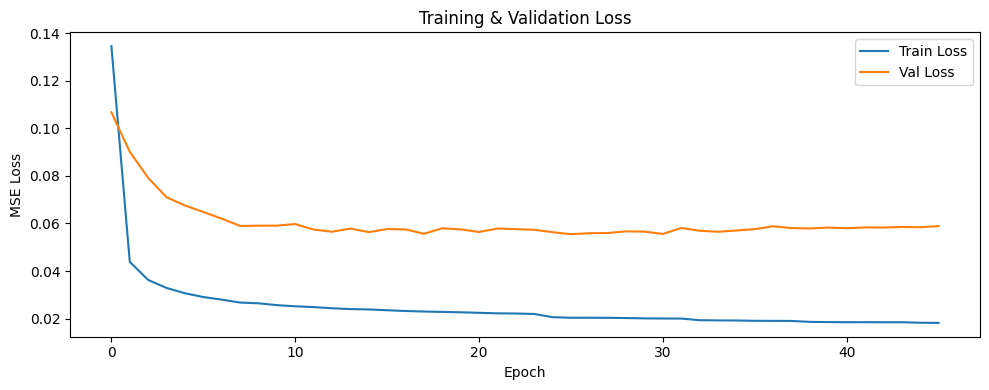

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

MAE:  16.9328
RMSE: 25.7249
MAPE: 11.0704%  (flow > 1 only)


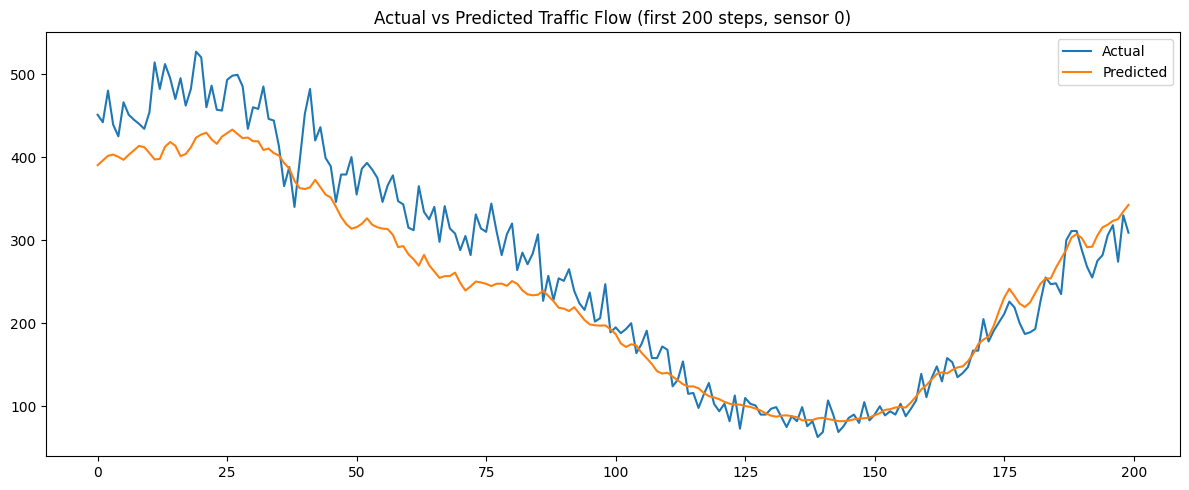

In [12]:
model.eval()
preds, actual = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device, non_blocking=True)
        preds.append(model(x).cpu().numpy())
        actual.append(y.numpy())

preds  = np.concatenate(preds)
actual = np.concatenate(actual)

# Denormalise
preds  = preds  * std + mean
actual = actual * std + mean

# Metrics
mae  = mean_absolute_error(actual.flatten(), preds.flatten())
rmse = np.sqrt(mean_squared_error(actual.flatten(), preds.flatten()))

# MAPE — skip near-zero flow
mask = actual.flatten() > 1.0
mape = np.mean(np.abs((actual.flatten()[mask] - preds.flatten()[mask]) /
                       actual.flatten()[mask])) * 100

print(f'MAE:  {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAPE: {mape:.4f}%  (flow > 1 only)')

# Plot
plt.figure(figsize=(12, 5))
plt.plot(actual[:200, 0, 0], label='Actual')
plt.plot(preds[:200,  0, 0], label='Predicted')
plt.legend()
plt.title('Actual vs Predicted Traffic Flow (first 200 steps, sensor 0)')
plt.tight_layout()
plt.show()